In [2]:
# 1. DAGSHUB & MLFLOW INITIALIZATION

!pip install dagshub mlflow scikit-learn -q

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import mlflow
import dagshub
import warnings
warnings.filterwarnings('ignore')

REPO_OWNER = "ejoba22"  
REPO_NAME = "walmart-sales-forecasting"

dagshub.init(repo_owner=REPO_OWNER, repo_name=REPO_NAME, mlflow=True)
mlflow.set_tracking_uri(f"https://dagshub.com/{REPO_OWNER}/{REPO_NAME}.mlflow")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=0a09482b-75fb-438b-8bad-4a981ce044c2&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=f0d512e76b5b3a6443868c60f6f0be0d481a48ee1a6819ae5f7ca73ec437bbe6




Output()

Accessing as tvada22

Initialized MLflow to track repo "ejoba22/walmart-sales-forecasting"

Repository ejoba22/walmart-sales-forecasting initialized!

In [3]:
# 2. DATA LOADING & PREPARATION
DATA_BASE_PATH = '/kaggle/input/notebooks/elenejobava/walmart-eda-feature-engineering/'

train_fe = pd.read_parquet(DATA_BASE_PATH + 'train_features.parquet')

# Kaggle WMAE Weights
train_fe['weight'] = np.where(train_fe['IsHoliday'] == 1, 5, 1)

features = [c for c in train_fe.columns if c not in ['Weekly_Sales', 'Date', 'Store_Dept', 'Type', 'weight']]
target = 'Weekly_Sales'

In [4]:
# 3. TIME-SERIES SPLIT
# Exactly the same 12-week split used for LightGBM to ensure fair comparison
split_date = train_fe['Date'].max() - pd.Timedelta(weeks=12)

X_train = train_fe[train_fe['Date'] <= split_date][features]
y_train = train_fe[train_fe['Date'] <= split_date][target]
w_train = train_fe[train_fe['Date'] <= split_date]['weight']

X_val = train_fe[train_fe['Date'] > split_date][features]
y_val = train_fe[train_fe['Date'] > split_date][target]
w_val = train_fe[train_fe['Date'] > split_date]['weight']

In [7]:
# 4. CUSTOM METRICS
def calculate_wape(y_true, y_pred):
    return (np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))) * 100

def calculate_wmae(y_true, y_pred, weights):
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

In [8]:
# 5. MODEL TRAINING & TRACKING
# Initialize the model with constraints to prevent Kaggle RAM crashes
rf_model = RandomForestRegressor(
    n_estimators=100,      # Build 100 independent trees
    max_depth=20,          # Restrict how deep trees can grow to save memory
    min_samples_leaf=20,   # Minimum 20 data points per leaf (Regularization)
    n_jobs=-1,             # Use all available CPU cores in parallel
    random_state=42
)

mlflow.set_experiment("RandomForest_Training")

# Enable automatic logging for scikit-learn
mlflow.sklearn.autolog()

with mlflow.start_run(run_name="RandomForest_Baseline"):
    
    # Train the model (Passing weights so it prioritizes holidays)
    rf_model.fit(X_train, y_train, sample_weight=w_train)
    
    val_preds = rf_model.predict(X_val)
    
    # Calculate Custom Metrics
    wmae_score = calculate_wmae(y_val, val_preds, w_val)
    wape_score = calculate_wape(y_val, val_preds)
    
    # Log the custom metrics alongside the default sklearn metrics
    mlflow.log_metric("validation_WMAE", wmae_score)
    mlflow.log_metric("validation_WAPE_percent", wape_score)

    print(f"Validation WMAE: {wmae_score:.2f}")
    print(f"Human-Readable Error (WAPE): {wape_score:.2f}%")

2026/07/10 20:30:59 INFO mlflow.tracking.fluent: Experiment with name 'RandomForest_Training' does not exist. Creating a new experiment.
2026/07/10 20:48:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Validation WMAE: 958.04
Human-Readable Error (WAPE): 6.01%
🏃 View run RandomForest_Baseline at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/4/runs/495eb36ccf9e4d9cb4652f257f91390e
🧪 View experiment at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/4



--- Testing max_depth=5 ---


2026/07/10 21:17:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train WAPE: 7.92% | Val WAPE: 8.34%
Status: OPTIMAL/BALANCED
🏃 View run RF_Depth_5 at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/4/runs/f6b6e60526594ccbbb9af496e1f862cb
🧪 View experiment at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/4

--- Testing max_depth=15 ---


2026/07/10 21:32:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train WAPE: 5.23% | Val WAPE: 6.06%
Status: OPTIMAL/BALANCED
🏃 View run RF_Depth_15 at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/4/runs/c5079444f2cc4a2da85116ed5d3d2be4
🧪 View experiment at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/4

--- Testing max_depth=30 ---


2026/07/10 21:50:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train WAPE: 4.86% | Val WAPE: 6.01%
Status: OPTIMAL/BALANCED
🏃 View run RF_Depth_30 at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/4/runs/b616619c746d4bf6927f19da98beef87
🧪 View experiment at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/4


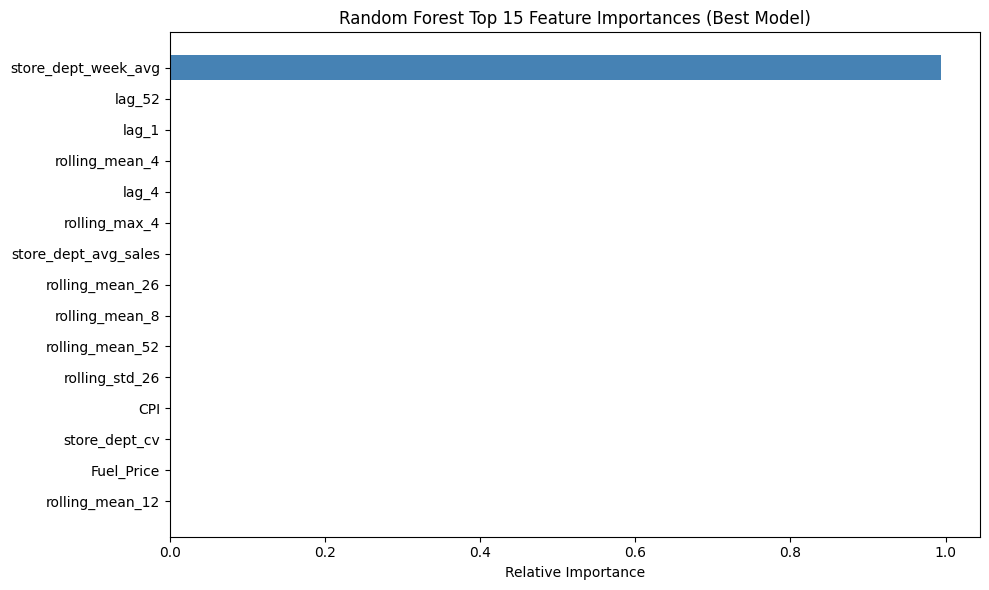

In [10]:
# analysis for undefitting/overfitting
import matplotlib.pyplot as plt

depths_to_test = [5, 15, 30]
best_model = None
best_wape = float('inf')

for depth in depths_to_test:
    print(f"\n--- Testing max_depth={depth} ---")
    
    with mlflow.start_run(run_name=f"RF_Depth_{depth}"):
        
        # 1. Initialize with current depth
        rf_model = RandomForestRegressor(
            n_estimators=100,      
            max_depth=depth,       
            min_samples_leaf=20,   
            n_jobs=-1,             
            random_state=42
        )
        
        # 2. Train the model
        rf_model.fit(X_train, y_train, sample_weight=w_train)
        
        # 3. Generate Predictions for BOTH Train and Validation
        train_preds = rf_model.predict(X_train)
        val_preds = rf_model.predict(X_val)
        
        # 4. Calculate Train & Val WAPE to prove the gap
        train_wape = calculate_wape(y_train, train_preds)
        val_wape = calculate_wape(y_val, val_preds)
        
        mlflow.log_metric("train_WAPE_percent", train_wape)
        mlflow.log_metric("validation_WAPE_percent", val_wape)
        mlflow.log_param("max_depth", depth)
        
        print(f"Train WAPE: {train_wape:.2f}% | Val WAPE: {val_wape:.2f}%")
        
        # Determine the state for your notes
        gap = val_wape - train_wape
        if train_wape > 10 and val_wape > 10:
            print("Status: UNDERFITTING (Model is too simple, high error everywhere)")
        elif gap > 3.0:
            print("Status: OVERFITTING (Memorizing train data, failing on val data)")
        else:
            print("Status: OPTIMAL/BALANCED")
            
        # Save the best model for feature importance plotting
        if val_wape < best_wape:
            best_wape = val_wape
            best_model = rf_model


importances = best_model.feature_importances_
indices = np.argsort(importances)[-15:]  # Top 15 features

plt.figure(figsize=(10, 6))
plt.title(f'Random Forest Top 15 Feature Importances (Best Model)')
plt.barh(range(len(indices)), importances[indices], color='steelblue', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()